In [1]:
from Qreservoir_fast import QReservoir
from tools import gen_input_states, gen_system_filepath, gen_result_filepath, write_to_row, finish_row, unpack_config, folder_name

import numpy as np
import matplotlib.pyplot as plt
import copy

# Reservoir hyperparameters

In [3]:
gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding, n_models, n_train_inputs, n_test_inputs = unpack_config("Qreservoir_configurations/config1.json")

# Generate new models, train inputs and their entanglement values

In [3]:
QReservoir_models = [QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding) for _ in range(n_models)]

for Qreservoir in QReservoir_models:
    Qreservoir.init_reservoir("vacuum")
    Qreservoir.rk4_timesteps(4)

In [4]:
train_ST_data = [list(gen_input_states("ST", n_test_inputs, fock_truncation, True, sim_rounding)) for _ in range(n_models)]
train_ST, train_ST_ent = [], []

for i in range(n_models):
    train_ST.append(train_ST_data[i][0])
    train_ST_ent.append(train_ST_data[i][1])

# Load pretrained models

In [3]:
QReservoir_models = []

for i in range(n_models):
    systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), i)
    Qres = QReservoir.init_from_file(systempath)
    QReservoir_models.append(Qres)

# Generate test inputs and their entanglement values

In [ ]:
test_ST_data = [list(gen_input_states("ST", n_test_inputs, fock_truncation, True, sim_rounding)) for _ in range(n_models)]
test_PASV_data = [list(gen_input_states("PASV_split", n_test_inputs, fock_truncation, True, sim_rounding)) for _ in range(n_models)]
test_PSSV_data = [list(gen_input_states("PSSV_split", n_test_inputs, fock_truncation, True, sim_rounding)) for _ in range(n_models)]
test_NUM_data = [list(gen_input_states("NUM_split", n_test_inputs, fock_truncation, True, sim_rounding)) for _ in range(n_models)]

test_ST, test_ST_ent, test_PASV, test_PASV_ent, test_PSSV, test_PSSV_ent, test_NUM, test_NUM_ent = [], [], [], [], [], [], [], []

for i in range(n_models):
    test_ST.append(test_ST_data[i][0])
    test_ST_ent.append(test_ST_data[i][1])
    test_PASV.append(test_PASV_data[i][0])
    test_PASV_ent.append(test_PASV_data[i][1])
    test_PSSV.append(test_PSSV_data[i][0])
    test_PSSV_ent.append(test_PSSV_data[i][1])
    test_NUM.append(test_NUM_data[i][0])
    test_NUM_ent.append(test_NUM_data[i][1])


# Model training for new systems

In [ ]:
for i in range(n_models):
    QReservoir_models[i].train_reservoir(train_ST[i], train_ST_ent[i])
    systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), i)
    QReservoir_models[i].system_save(systempath)

In [7]:
system_idx = 7
QReservoir_models[system_idx] = QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding)
train_ST[system_idx], train_ST_ent[system_idx] = gen_input_states("ST", n_test_inputs, fock_truncation, True, sim_rounding)

QReservoir_models[system_idx].init_reservoir("vacuum")
QReservoir_models[system_idx].rk4_timesteps(4)

In [ ]:
QReservoir_models[system_idx].train_reservoir(train_ST[system_idx], train_ST_ent[system_idx])
systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), system_idx)
QReservoir_models[system_idx].system_save(systempath)

# Test models / Evaluate entanglement classification

In [9]:
resultpath = gen_result_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity))
resultpath_cm = gen_result_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity, True))

# Squeezed thermal states

In [ ]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result, cm = QReservoir_models[i].test_reservoir(test_ST[i], test_ST_ent[i])
    write_to_row(str(result), resultpath)
    write_to_row(','.join(map(str, cm)), resultpath_cm)

finish_row(resultpath)
finish_row(resultpath_cm)

# Photon added squeezed vacuum states

In [ ]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result, cm = QReservoir_models[i].test_reservoir(test_PASV[i], test_PASV_ent[i])
    write_to_row(str(result), resultpath)
    write_to_row(','.join(map(str, cm)), resultpath_cm)

finish_row(resultpath)
finish_row(resultpath_cm)

# Photon substracted squeezed vacuum states

In [ ]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result, cm = QReservoir_models[i].test_reservoir(test_PSSV[1], test_PSSV_ent[1])
    write_to_row(str(result), resultpath)
    write_to_row(','.join(map(str, cm)), resultpath_cm)

finish_row(resultpath)
finish_row(resultpath_cm)

# Number states

In [ ]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result, cm = QReservoir_models[i].test_reservoir(test_NUM[i], test_NUM_ent[i])
    write_to_row(str(result), resultpath)
    write_to_row(','.join(map(str, cm)), resultpath_cm)

finish_row(resultpath)
finish_row(resultpath_cm)

# Visualize the performance with histograms and confusion matrices

# Read data and convert it into a usable format

In [2]:
datas = []
datas_mean = []
datas_std = []
datas_cm = []
models_filenames = ['1_4_5_alltoall', '1_4_5_ring', '1_4_5_sausage', '1_3_5_alltoall', '1_3_5_sausage', '1_2_5_alltoall']
data_filepaths = ["Qreservoir_results/" + filename + ".csv" for filename in models_filenames]
data_cm_filepaths = ["Qreservoir_results/" + filename + "_cm.csv" for filename in models_filenames]

for path in data_filepaths:
    data = np.genfromtxt(path, delimiter=';')[:,:-1]
    data[2] = 1 - data[2]
    datas.append(data)
    datas_mean.append(np.mean(data, axis=1))
    datas_std.append(np.std(data, axis=1, ddof=1))

datas_full = np.array(datas).reshape(-1,np.array(datas).shape[-1])
datas_mean_full = np.mean(datas_full, axis=1)
datas_std_full = np.std(datas_full, axis=1, ddof=1)

for path in data_cm_filepaths:
    with open(path) as raw_data_cm:
        data_cm = np.array([[np.fromstring(round, sep=",") for round in class_of_input.strip().split(";") if len(round) > 1] for class_of_input in raw_data_cm])
        data_cm[2] = 100 - data_cm[2]
        datas_cm.append(data_cm)

datas_cm_full = np.array([[np.sum(input, axis=0) for input in model]for model in datas_cm])
datas_cm_full_norm = copy.copy(datas_cm_full)
datas_cm_full_norm[:,0,[0,2]] = datas_cm_full_norm[:,0,[0,2]] / np.sum(datas_cm_full_norm[:,0,[0,2]], axis=1)[:,None]
datas_cm_full_norm[:,0,[1,3]] = datas_cm_full_norm[:,0,[1,3]] / np.sum(datas_cm_full_norm[:,0,[1,3]], axis=1)[:,None]
datas_cm_full_norm[:,1:,] = datas_cm_full_norm[:,1:,] / 1000
datas_cm_full_norm = np.round(datas_cm_full_norm,2)

input_types = ['ST', 'PASV', 'PSSV', 'NUM']
models = ['4-mode FULL', '4-mode RING', '4-mode SAUSAGE', '3-mode FULL', '3-mode SAUSAGE', '2-mode FULL']
plotcolors = [
    "#f0976e",
    "#f2cc6d",
    "#f3f17c",
    "#d1f27d",
    "#8def7a",
    "#7ff0c5"
]

In [5]:
datas_mean

[array([0.921, 0.666, 0.781, 0.702]),
 array([0.921 , 0.6685, 0.837 , 0.714 ]),
 array([0.9155, 0.6285, 0.89  , 0.7135]),
 array([0.858 , 0.67  , 0.9575, 0.715 ]),
 array([0.8285, 0.648 , 0.978 , 0.711 ]),
 array([0.8155, 0.635 , 0.978 , 0.735 ])]

In [6]:
datas_std

[array([0.04325634, 0.10079683, 0.11261537, 0.05170429]),
 array([0.05486347, 0.0730696 , 0.13725888, 0.04909175]),
 array([0.02910231, 0.10214505, 0.09501462, 0.04631115]),
 array([0.05954457, 0.07003967, 0.03758324, 0.02198484]),
 array([0.07583059, 0.02371123, 0.02907844, 0.03672722]),
 array([0.08722417, 0.07699206, 0.03838402, 0.0335824 ])]

# Histograms for each model

<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\h'
C:\Users\johan\AppData\Local\Temp\ipykernel_9428\1437823690.py:11: SyntaxWarning: invalid escape sequence '\h'
  plt.savefig('figures\hist_' + models_filenames[i] + '.png', bbox_inches='tight')


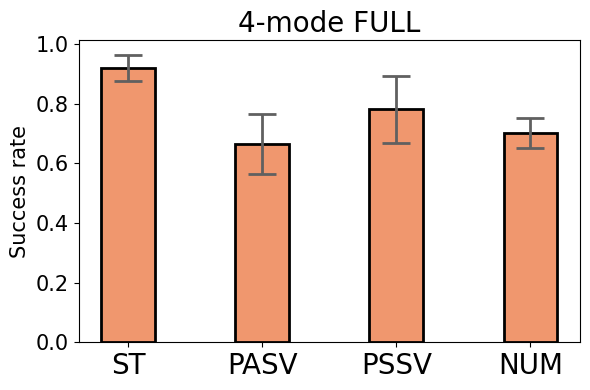

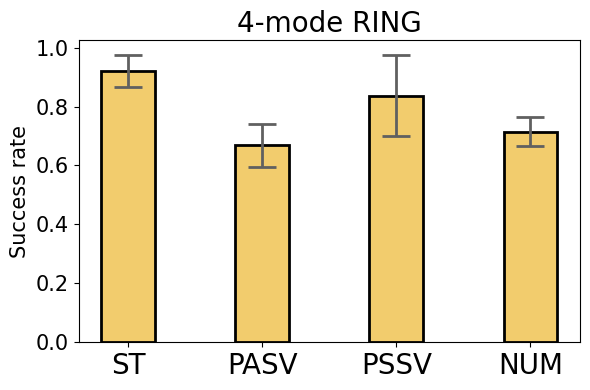

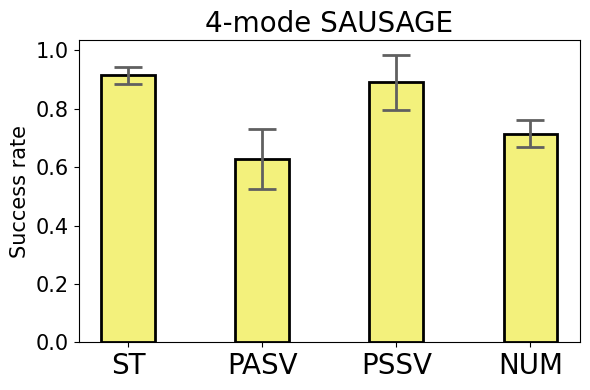

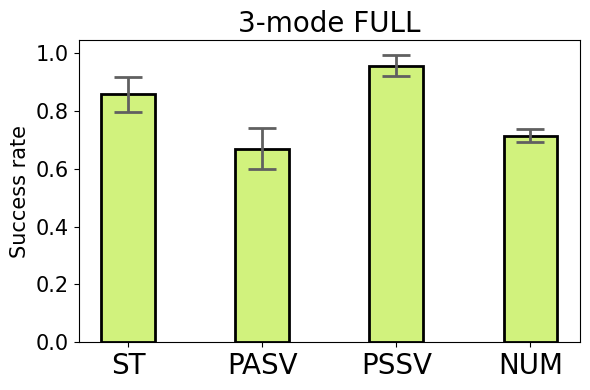

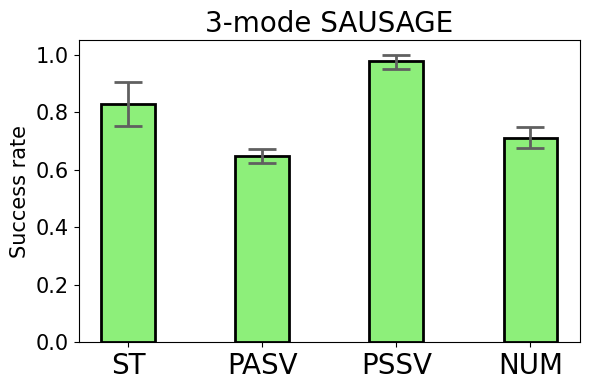

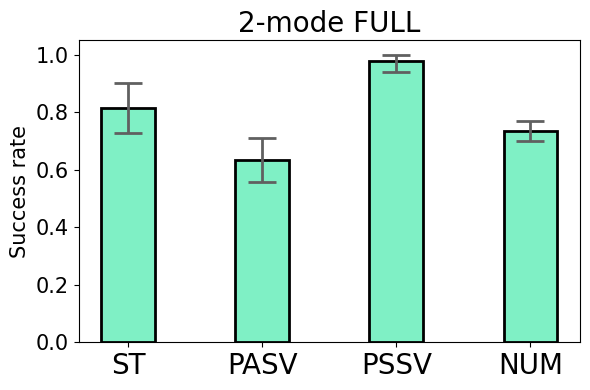

In [3]:
#Plot the probability of correct classification
for i, model in enumerate(models):
    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(input_types, datas_mean[i], 0.4, yerr=[datas_std[i], datas_std[i] - (np.maximum(datas_mean[i]+datas_std[i],1) - 1)], color=plotcolors[i], ecolor="#606060", error_kw={'elinewidth': 2.0, 'capthick': 2.0}, capsize=10, edgecolor='black', linewidth=2.0)

    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=20)
    ax.set_ylabel('Success rate', fontsize=15)
    plt.title(model, fontsize=20)
    plt.tight_layout()
    plt.savefig('figures\hist_' + models_filenames[i] + '.png', bbox_inches='tight')
    plt.show()

# Confusion matrices for each model

<>:24: SyntaxWarning: invalid escape sequence '\c'
<>:24: SyntaxWarning: invalid escape sequence '\c'
C:\Users\johan\AppData\Local\Temp\ipykernel_9428\1310743973.py:24: SyntaxWarning: invalid escape sequence '\c'
  plt.savefig('figures\cm_' + filename + '.png', bbox_inches='tight')


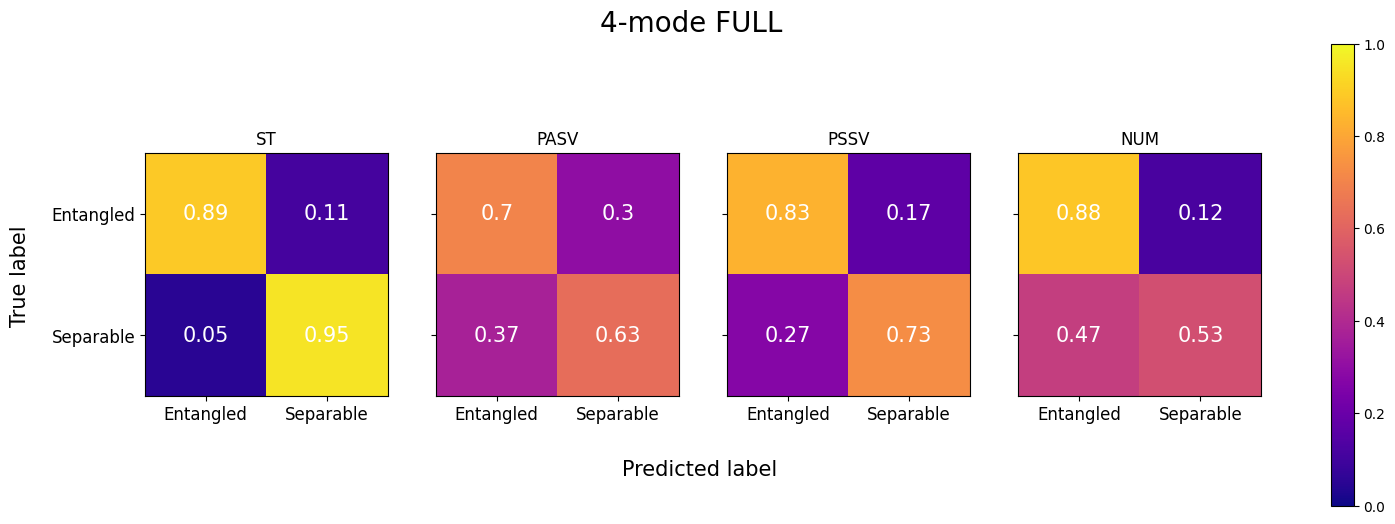

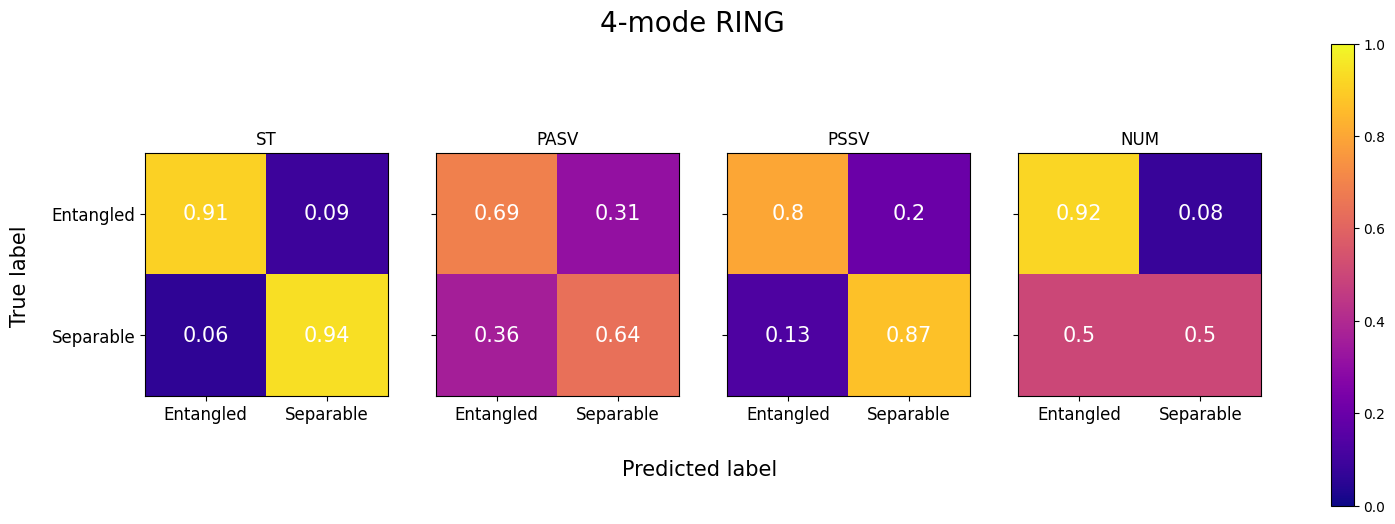

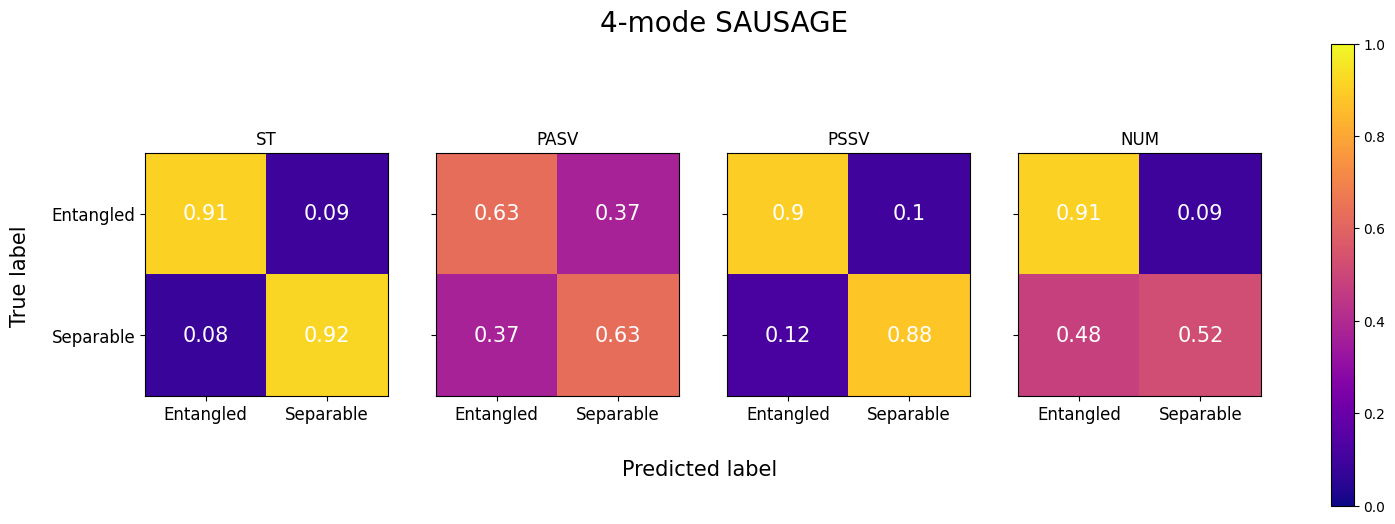

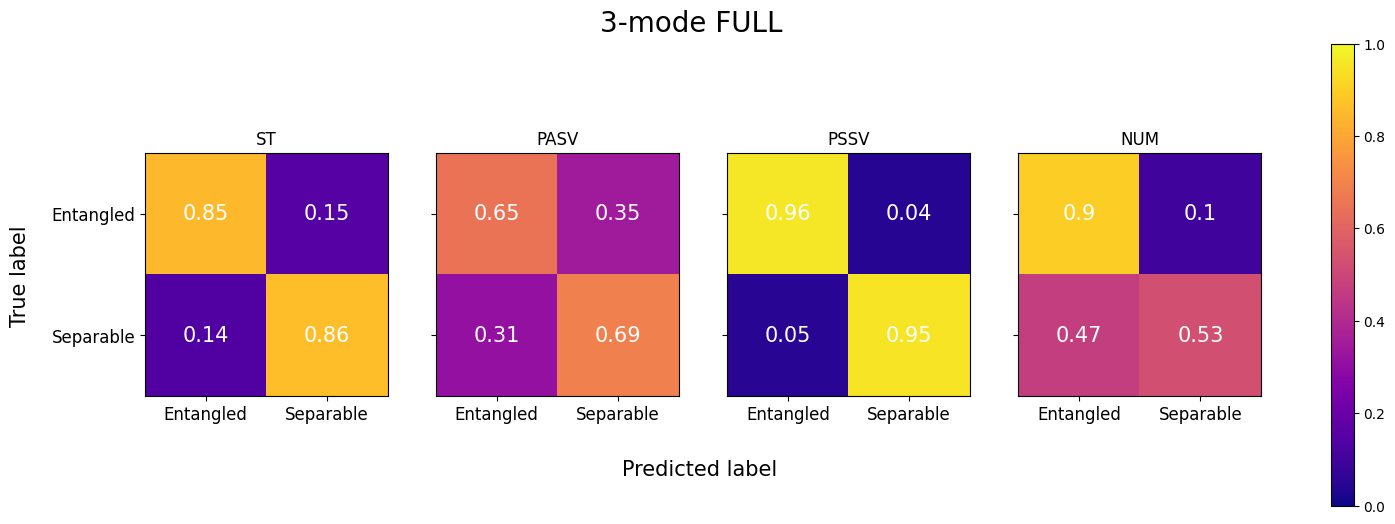

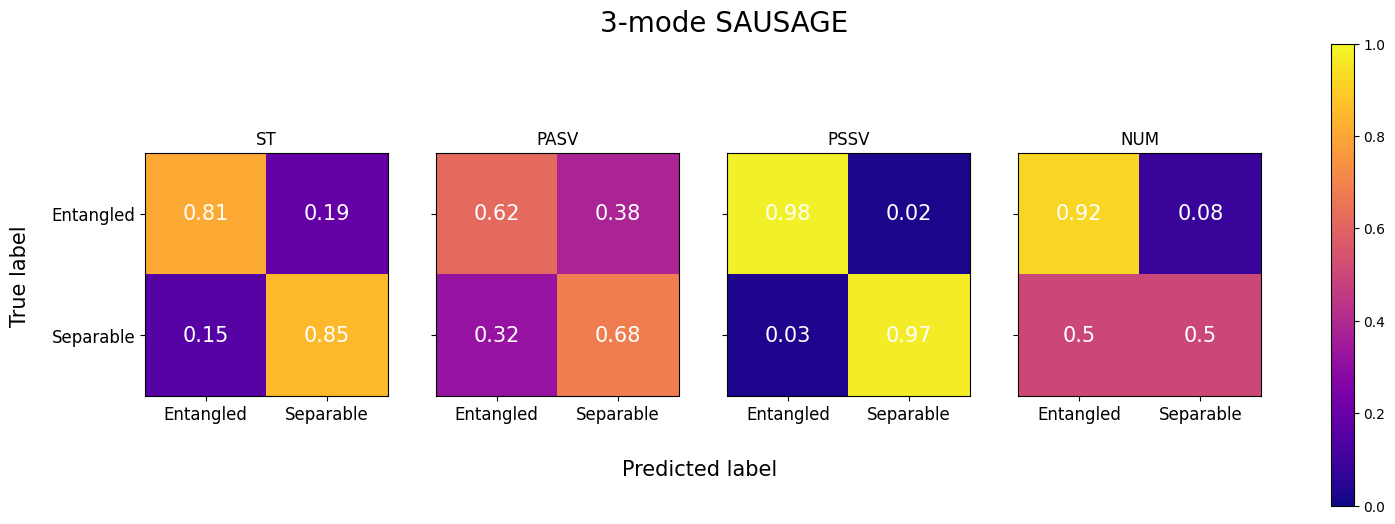

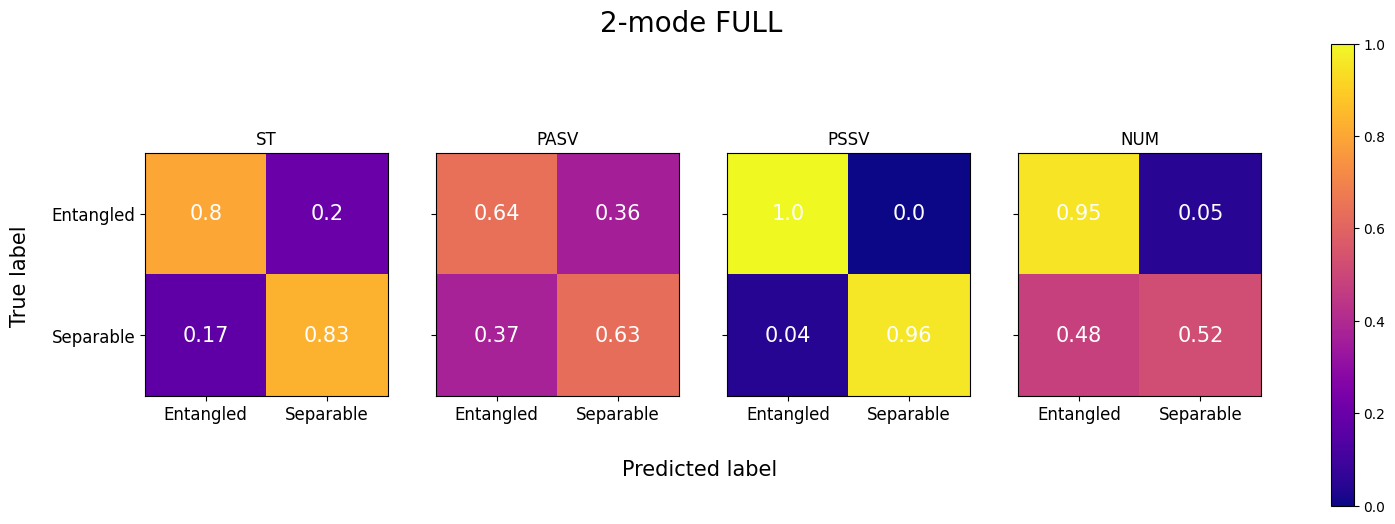

In [4]:
for filename, model, cm_data in zip(models_filenames,models,datas_cm_full_norm):

    fig, axes = plt.subplots(1, len(input_types), figsize=(18, 6))

    for i, cm in enumerate(cm_data):
        cm = np.array([[cm[0], cm[2]],[cm[3], cm[1]]])
        im = axes[i].imshow(cm, cmap='plasma', vmin=0, vmax=1.0)

        for k in range(2):
            for l in range(2):
                axes[i].text(k, l, cm[l, k], ha='center', va='center', fontsize=15, color='white')

        axes[i].set_xticks([0,1],["Entangled", "Separable"],fontsize=12)
        if i == 0:
            axes[i].set_yticks([0,1],["Entangled", "Separable"],fontsize=12)
        else:
            axes[i].set_yticks([0,1],["", ""])
        axes[i].set_title((input_types[i]))

    fig.colorbar(im, ax=axes.ravel().tolist())
    fig.text(0.39, 0.16,'Predicted label',fontsize=15)
    fig.text(0.05, 0.415,'True label',rotation=90,fontsize=15)
    fig.text(0.3775,0.9,model,fontsize=20)
    plt.savefig('figures\cm_' + filename + '.png', bbox_inches='tight')
    plt.show()

# A combined histogram for all models

<>:26: SyntaxWarning: invalid escape sequence '\h'
<>:26: SyntaxWarning: invalid escape sequence '\h'
C:\Users\johan\AppData\Local\Temp\ipykernel_9428\813742857.py:26: SyntaxWarning: invalid escape sequence '\h'
  plt.savefig('figures\hist_combinedresults.png', bbox_inches='tight')


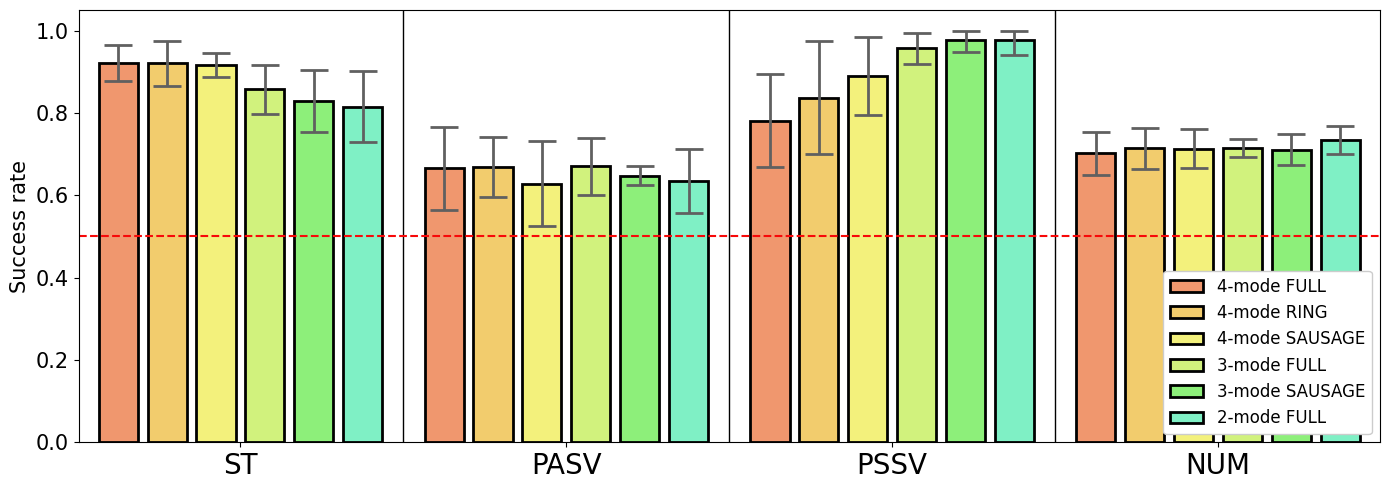

In [5]:
fig, ax = plt.subplots(figsize=(14,5))

index = np.arange(len(input_types))
bar_width = 0.12
bar_gap = 0.03

ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', labelsize=20)
ax.set_ylabel('Success rate', fontsize=15)
ax.set_ylim(0,1.05)

for i in range(len(models)):
    ax.bar(index + i * (bar_width + bar_gap), datas_mean[i], bar_width, yerr=[datas_std[i], datas_std[i] - (np.maximum(datas_mean[i]+datas_std[i],1) - 1)], color=plotcolors[i], ecolor="#606060", error_kw={'elinewidth': 2.0, 'capthick': 2.0}, capsize=10, edgecolor='black', linewidth=2.0, label=models[i])

for group in range(1, len(input_types)):
    ax.axvline(group - 0.125, color='black', linewidth=1, zorder= 0)

ax.axhline(0.5, c="#f70909", linestyle='--', linewidth=1.5, zorder = 2)

group_width = len(models) * (bar_width + bar_gap) - bar_gap
plt.xticks(index + group_width / 2 - bar_width / 2, input_types)

plt.margins(x=0.016)
plt.legend(loc='lower right', fontsize=12, framealpha=1.0)
plt.tight_layout()
plt.savefig('figures\hist_combinedresults.png', bbox_inches='tight')
plt.show()

In [7]:
from scipy.stats import spearmanr

In [17]:
for i in range(6):
    cor, pmat = spearmanr(datas[i], axis=1)

    print(np.round(cor,2))
    print()
    print(np.round(pmat,3))
    print()
    print()
    print()

[[ 1.   -0.05  0.61  0.13]
 [-0.05  1.    0.09 -0.07]
 [ 0.61  0.09  1.    0.35]
 [ 0.13 -0.07  0.35  1.  ]]

[[0.    0.88  0.059 0.712]
 [0.88  0.    0.802 0.855]
 [0.059 0.802 0.    0.316]
 [0.712 0.855 0.316 0.   ]]



[[ 1.    0.29  0.12 -0.16]
 [ 0.29  1.   -0.3   0.01]
 [ 0.12 -0.3   1.    0.22]
 [-0.16  0.01  0.22  1.  ]]

[[0.    0.422 0.75  0.649]
 [0.422 0.    0.405 0.987]
 [0.75  0.405 0.    0.533]
 [0.649 0.987 0.533 0.   ]]



[[ 1.    0.38 -0.38  0.13]
 [ 0.38  1.   -0.22  0.79]
 [-0.38 -0.22  1.   -0.12]
 [ 0.13  0.79 -0.12  1.  ]]

[[0.    0.275 0.283 0.711]
 [0.275 0.    0.533 0.006]
 [0.283 0.533 0.    0.737]
 [0.711 0.006 0.737 0.   ]]



[[ 1.    0.24 -0.64 -0.62]
 [ 0.24  1.   -0.23 -0.12]
 [-0.64 -0.23  1.    0.2 ]
 [-0.62 -0.12  0.2   1.  ]]

[[0.    0.498 0.047 0.056]
 [0.498 0.    0.531 0.735]
 [0.047 0.531 0.    0.574]
 [0.056 0.735 0.574 0.   ]]



[[ 1.    0.02 -0.46  0.14]
 [ 0.02  1.   -0.6  -0.15]
 [-0.46 -0.6   1.   -0.37]
 [ 0.14 -0.15 -0.37  1.  ]]

[[